# TT-09 — AdaBoost: Phát hiện xâm nhập mạng trong hệ thống giám sát an ninh (SOC)

**Bài toán:** SOC cần phân loại mỗi kết nối mạng là `normal` hay `attack`.
Bỏ sót tấn công thật (Recall) và báo động giả quá nhiều gây "alert fatigue"
(Precision) đều tốn kém — cần F1/F2.

Notebook này đi theo đúng 10 bước trong `README.md` cấp đề, giải thích **vì
sao** làm từng bước chứ không chỉ chạy code. Toàn bộ số liệu bên dưới là kết
quả chạy thật trên bộ dữ liệu NSL-KDD gốc (không phải số minh hoạ) — script
tương đương để tái lập tự động: `src/train.py`.

## 1. Nạp dữ liệu NSL-KDD, gộp nhãn thành nhị phân

Bộ dữ liệu gồm 41 đặc trưng kết nối mạng + nhãn cụ thể loại tấn công (`label`)
+ `difficulty_level`. Xem nguồn tải cụ thể tại `data/DATA_SOURCE.md`.

Việc đầu tiên: gộp nhãn cụ thể (`normal`, `neptune`, `satan`, ...) thành bài
toán **nhị phân** `normal` (0) vs `attack` (1) — vì lớp U2R quá hiếm
(~0,04%) để học riêng, và SOC thực tế thường cần quyết định nhị phân trước
(có đáng ngờ hay không), rồi mới phân loại chi tiết sau.

In [1]:
%matplotlib inline
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
N_ESTIMATORS = 300
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FEATURE_COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
]
ALL_COLUMNS = FEATURE_COLUMNS + ["label", "difficulty_level"]
CATEGORICAL_COLS = ["protocol_type", "service", "flag"]
NUMERIC_COLS = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_COLS]

ATTACK_CATEGORY = {
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "apache2": "DoS", "udpstorm": "DoS", "processtable": "DoS",
    "worm": "DoS", "mailbomb": "DoS",
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    "mscan": "Probe", "saint": "Probe",
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L",
    "phf": "R2L", "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "snmpguess": "R2L", "snmpgetattack": "R2L",
    "httptunnel": "R2L", "sendmail": "R2L", "named": "R2L",
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
    "ps": "U2R", "sqlattack": "U2R", "xterm": "U2R",
}

def load_raw(path):
    df = pd.read_csv(path, names=ALL_COLUMNS, header=None)
    df["binary_label"] = (df["label"] != "normal").astype(int)
    df["attack_category"] = np.where(
        df["label"] == "normal", "Normal", df["label"].map(ATTACK_CATEGORY).fillna("Unknown")
    )
    return df

train_df = load_raw("../data/KDDTrain+.txt")
test_df = load_raw("../data/KDDTest+.txt")
print(f"Train: {len(train_df):,} dong, {train_df.shape[1]} cot")
print(f"Test : {len(test_df):,} dong")
train_df["binary_label"].value_counts().rename({0: "normal", 1: "attack"})

Train: 125,973 dong, 45 cot
Test : 22,544 dong


binary_label
normal    67343
attack    58630
Name: count, dtype: int64

In [2]:
attack_rate_train = train_df["binary_label"].mean()
attack_rate_test = test_df["binary_label"].mean()
print(f"Ty le attack - train: {attack_rate_train:.2%}")
print(f"Ty le attack - test : {attack_rate_test:.2%}")

u2r_share = (train_df["attack_category"] == "U2R").mean()
print(f"Ty le lop U2R (train): {u2r_share:.4%} -> qua hiem de hoc rieng, dung nhi phan truoc")

Ty le attack - train: 46.54%
Ty le attack - test : 56.92%
Ty le lop U2R (train): 0.0413% -> qua hiem de hoc rieng, dung nhi phan truoc


## 2. Tiền xử lý: one-hot 3 cột phân loại, scale các cột số

`protocol_type` (3 mức), `flag` (11 mức), `service` (~70 mức) là dạng phân
loại → `OneHotEncoder`. Bốn mươi mốt cột số còn lại có thang đo rất khác nhau
(`duration` tính bằng giây, các cột `*_rate` trong [0,1]) → `StandardScaler`.

**Quan trọng:** `OneHotEncoder(handle_unknown="ignore")` vì tập test có vài
giá trị `service` không xuất hiện trong tập train — nếu không xử lý sẽ lỗi
khi transform. Toàn bộ bước này nằm trong `ColumnTransformer`, luôn **fit chỉ
trên train** để tránh rò rỉ thống kê từ test vào train.

In [3]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ("num", StandardScaler(), NUMERIC_COLS),
    ])

X_train_full = train_df[FEATURE_COLUMNS]
y_train_full = train_df["binary_label"].to_numpy()
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df["binary_label"].to_numpy()

preprocessor = build_preprocessor()
Xtr_full_mat = preprocessor.fit_transform(X_train_full)
Xtest_mat = preprocessor.transform(X_test)
print(f"So chieu truoc one-hot: {len(FEATURE_COLUMNS)}  ->  sau one-hot: {Xtr_full_mat.shape[1]}")

So chieu truoc one-hot: 41  ->  sau one-hot: 122


## 3. EDA: phân bố loại tấn công, tỉ lệ normal/attack

`attack_category` gộp các nhãn cụ thể thành 4 nhóm chuẩn NSL-KDD: **DoS**
(làm ngập dịch vụ), **Probe** (dò quét trước khi tấn công), **R2L**
(chiếm quyền truy cập từ xa), **U2R** (leo thang đặc quyền cục bộ — hiếm
nhất và khó phát hiện nhất).

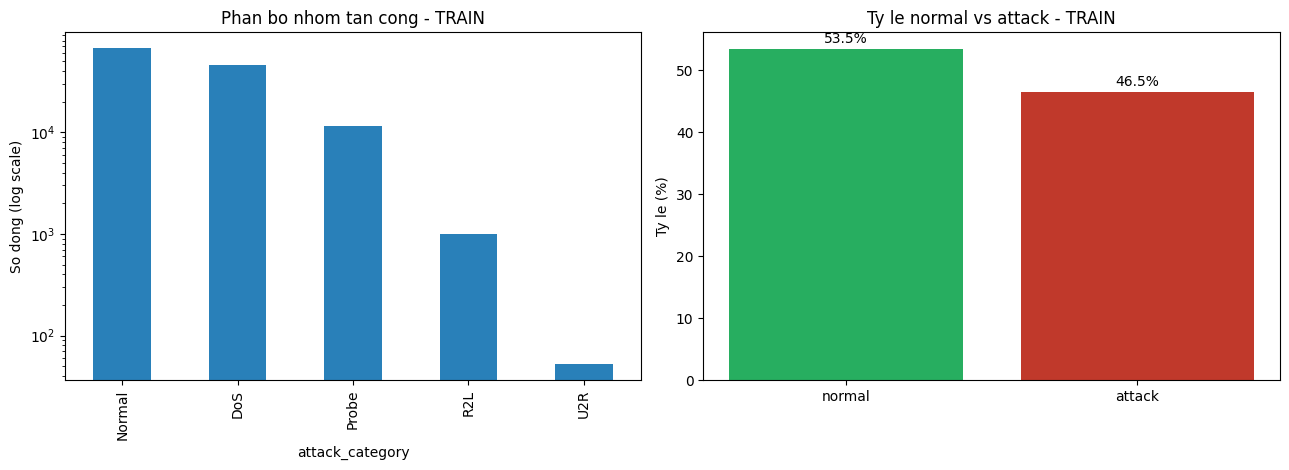

,train,test
attack_category,,
DoS,45927,7460
Normal,67343,9711
Probe,11656,2421
R2L,995,2885
U2R,52,67


In [4]:
cat_train = train_df["attack_category"].value_counts()
cat_test = test_df["attack_category"].value_counts()
cat_table = pd.DataFrame({"train": cat_train, "test": cat_test}).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
cat_table["train"].sort_values(ascending=False).plot.bar(ax=axes[0], color="#2980b9")
axes[0].set_title("Phan bo nhom tan cong - TRAIN")
axes[0].set_yscale("log")
axes[0].set_ylabel("So dong (log scale)")

ratio = train_df["binary_label"].value_counts(normalize=True).rename({0: "normal", 1: "attack"})
axes[1].bar(ratio.index.astype(str), ratio.values * 100, color=["#27ae60", "#c0392b"])
axes[1].set_title("Ty le normal vs attack - TRAIN")
axes[1].set_ylabel("Ty le (%)")
for i, v in enumerate(ratio.values * 100):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center")
fig.tight_layout()
plt.show()

cat_table

### ⚠️ Bẫy dữ liệu: tập test chứa loại tấn công KHÔNG có trong train

Đây là thiết kế **cố ý** của NSL-KDD để mô phỏng tấn công zero-day — mô hình
train xong sẽ gặp những mẫu tấn công nó **chưa từng thấy dạng nào tương tự**
ở bước 9. Điểm số trên tập test này chắc chắn sẽ thấp hơn CV — đó là điều
**đúng**, không phải lỗi.

In [5]:
unseen_labels = sorted(set(test_df["label"]) - set(train_df["label"])) #có những loại attack nào xuất hiện trong test mà không có trong train?
print(f"So loai tan cong CHI xuat hien trong test: {len(unseen_labels)}")
print(unseen_labels)
print(f"\nSo dong test thuoc cac loai tan cong la (zero-day mo phong): "
      f"{test_df['label'].isin(unseen_labels).sum():,} / {len(test_df):,}")

So loai tan cong CHI xuat hien trong test: 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']

So dong test thuoc cac loai tan cong la (zero-day mo phong): 3,750 / 22,544


## 4. Baseline: DummyClassifier + 1 stump đơn lẻ (depth=1)

Trước khi tin vào AdaBoost, cần biết mức sàn. Một **stump** (cây quyết định
sâu 1, chỉ hỏi đúng 1 câu hỏi) là chính weak learner mà AdaBoost dùng — nếu
1 stump đã mạnh thì boosting chẳng có gì để chứng minh. Đánh giá bằng
**5-fold StratifiedKFold cross-validation** trên toàn bộ train để có ước
lượng ổn định (không phụ thuộc 1 lần chia ngẫu nhiên).

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "Baseline (Dummy)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "1 Stump (depth=1)": DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
}

cv_rows = []
for name, clf in candidates.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("clf", clf)])
    scores = cross_validate(pipe, X_train_full, y_train_full, cv=skf,
                             scoring=("accuracy", "f1"), n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
    })
    print(f"{name:20s} Accuracy={cv_rows[-1]['cv_accuracy_mean']:.4f}  F1={cv_rows[-1]['cv_f1_mean']:.4f}")

Baseline (Dummy)     Accuracy=0.5029  F1=0.4667
1 Stump (depth=1)    Accuracy=0.9221  F1=0.9161


## 5. ⭐ AdaBoost 300 stump — so sánh với 1 stump đơn lẻ

```
α_m = ½·ln((1 − err_m) / err_m)
```

Mỗi stump thứ *m* được gán "tiếng nói" `α_m` tỉ lệ nghịch với sai số của nó —
stump chính xác hơn có quyền biểu quyết mạnh hơn trong tổng có trọng số cuối
cùng. Sau mỗi vòng, các mẫu bị phân **sai** được tăng trọng số, buộc stump kế
tiếp phải chú ý vào đúng những điểm khó.

In [8]:
ada_cv = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=N_ESTIMATORS, learning_rate=0.5, random_state=RANDOM_STATE,
)
pipe = Pipeline([("prep", build_preprocessor()), ("clf", ada_cv)])
t0 = time.perf_counter()
scores = cross_validate(pipe, X_train_full, y_train_full, cv=skf,
                         scoring=("accuracy", "f1"), n_jobs=-1)
elapsed = time.perf_counter() - t0
cv_rows.append({
    "model": f"AdaBoost ({N_ESTIMATORS} stump)",
    "cv_accuracy_mean": scores["test_accuracy"].mean(),
    "cv_f1_mean": scores["test_f1"].mean(),
})
ada_cv_f1 = cv_rows[-1]["cv_f1_mean"]
print(f"AdaBoost ({N_ESTIMATORS} stump)   Accuracy={cv_rows[-1]['cv_accuracy_mean']:.4f}  "
      f"F1={ada_cv_f1:.4f}  [{elapsed:.1f}s]")

cv_table = pd.DataFrame(cv_rows)
cv_table

AdaBoost (300 stump)   Accuracy=0.9849  F1=0.9836  [207.8s]


,model,cv_accuracy_mean,cv_f1_mean
0,Baseline (Dummy),0.5029,0.4667
1,1 Stump (depth=1),0.9221,0.9161
2,AdaBoost (300 stump),0.9849,0.9836


**Nhận xét:** so với 1 stump đơn lẻ, 300 stump kết hợp có trọng số nâng F1
lên đáng kể — đây chính là minh chứng cho sức mạnh của boosting: nhiều "weak
learner" yếu, khi được tổ hợp đúng cách (đánh trọng số mẫu + đánh trọng số
cây), tạo thành một "strong learner".

## 6. Đường Accuracy/F1 theo số vòng lặp (n_estimators = 1..300)

Để xem boosting cải thiện dần thế nào qua từng vòng, ta tách riêng
80% train_sub / 20% validation (stratify theo nhãn), fit **một lần** AdaBoost
với 300 stump, rồi dùng `staged_predict` để lấy dự đoán **tích luỹ** sau mỗi
vòng — không cần huấn luyện lại 300 lần.

train_sub=100,778  val=25,195


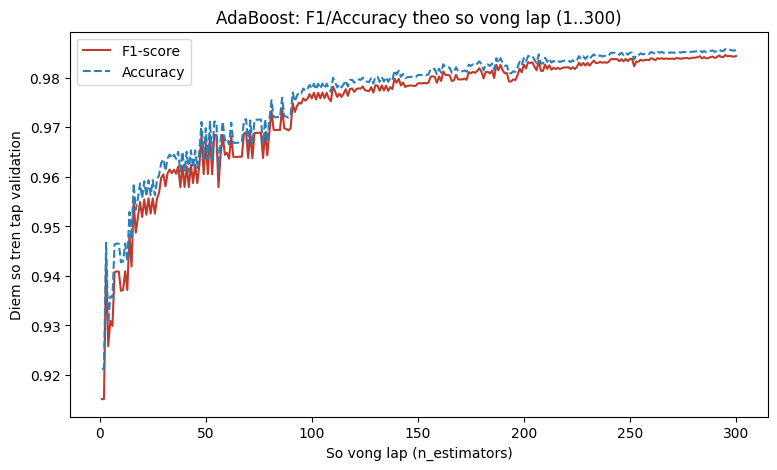

F1 tai n=1  : 0.9151
F1 tai n=300: 0.9843


In [ ]:
Xtr_sub, Xval, ytr_sub, yval = train_test_split(
    Xtr_full_mat, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE)
print(f"train_sub={Xtr_sub.shape[0]:,}  val={Xval.shape[0]:,}")

ada_clean = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=N_ESTIMATORS, learning_rate=0.5, random_state=RANDOM_STATE,
)
ada_clean.fit(Xtr_sub, ytr_sub)

curve_rows = []
for i, pred in enumerate(ada_clean.staged_predict(Xval), start=1):
    curve_rows.append({"n_estimators": i, "accuracy": accuracy_score(yval, pred), "f1": f1_score(yval, pred)})
curve = pd.DataFrame(curve_rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve["n_estimators"], curve["f1"], label="F1-score", color="#c0392b")
ax.plot(curve["n_estimators"], curve["accuracy"], label="Accuracy", color="#2980b9", ls="--")
ax.set_xlabel("So vong lap (n_estimators)")
ax.set_ylabel("Diem so tren tap validation")
ax.set_title(f"AdaBoost: F1/Accuracy theo so vong lap (1..{N_ESTIMATORS})")
ax.legend()
plt.show()

print(f"F1 tai n=1  : {curve['f1'].iloc[0]:.4f}")
print(f"F1 tai n={N_ESTIMATORS}: {curve['f1'].iloc[-1]:.4f}")

## 7. ⭐ THÍ NGHIỆM NHIỄU NHÃN — điểm yếu chí mạng của AdaBoost

AdaBoost tăng trọng số các mẫu bị phân sai **sau mỗi vòng**. Một mẫu bị gán
**nhãn sai** (label noise) sẽ luôn bị phân "sai" theo nhãn gán nhầm đó, nên
trọng số của nó tăng liên tục qua các vòng — đến một lúc, model dồn phần lớn
"sự chú ý" vào đúng những điểm rác này thay vì học pattern thật.

Random Forest không có cơ chế đánh trọng số lại mẫu theo lỗi (mỗi cây học
độc lập trên 1 bootstrap sample), nên **về lý thuyết** ít nhạy với nhiễu nhãn
hơn nhiều. Ta kiểm chứng bằng thực nghiệm: đảo ngẫu nhiên 5% nhãn tập train,
huấn luyện lại cả hai, rồi so F1 trên **cùng tập validation sạch**.

Da dao nguoc 5,038 / 100,778 nhan train (5%)


AdaBoost         F1 sach=0.9843  F1 nhieu 5%=0.9730  sut giam=0.0113


Random Forest    F1 sach=0.9990  F1 nhieu 5%=0.9927  sut giam=0.0062


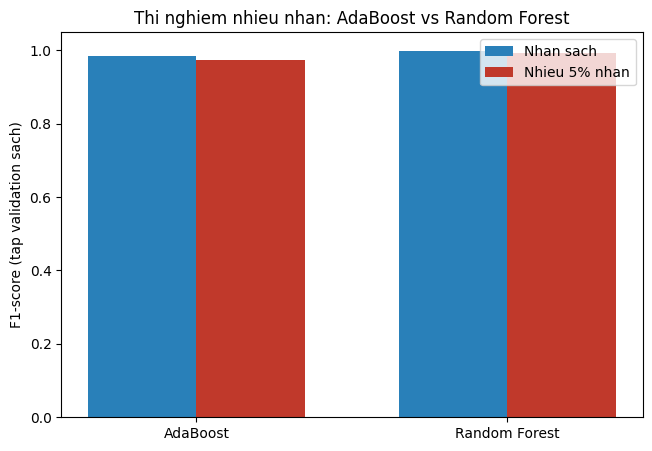

,model,f1_clean,f1_noisy_5pct,sut_giam_f1
0,AdaBoost,0.9843,0.9730,0.0113
1,Random Forest,0.9990,0.9927,0.0062


In [ ]:
rng = np.random.RandomState(RANDOM_STATE)
NOISE_FRACTION = 0.05
n_flip = int(NOISE_FRACTION * len(ytr_sub))
flip_idx = rng.choice(len(ytr_sub), size=n_flip, replace=False)
ytr_noisy = ytr_sub.copy()
ytr_noisy[flip_idx] = 1 - ytr_noisy[flip_idx]
print(f"Da dao nguoc {n_flip:,} / {len(ytr_sub):,} nhan train ({NOISE_FRACTION:.0%})")

rf_clean = RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=None,
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_clean.fit(Xtr_sub, ytr_sub)

ada_noisy = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                n_estimators=N_ESTIMATORS, learning_rate=0.5, random_state=RANDOM_STATE)
ada_noisy.fit(Xtr_sub, ytr_noisy)

rf_noisy = RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=None,
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_noisy.fit(Xtr_sub, ytr_noisy)

noise_rows = []
for name, clean_m, noisy_m in [("AdaBoost", ada_clean, ada_noisy), ("Random Forest", rf_clean, rf_noisy)]:
    f1_c = f1_score(yval, clean_m.predict(Xval))
    f1_n = f1_score(yval, noisy_m.predict(Xval))
    noise_rows.append({"model": name, "f1_clean": f1_c, "f1_noisy_5pct": f1_n, "sut_giam_f1": f1_c - f1_n})
    print(f"{name:16s} F1 sach={f1_c:.4f}  F1 nhieu 5%={f1_n:.4f}  sut giam={f1_c - f1_n:.4f}")

noise_table = pd.DataFrame(noise_rows)

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(noise_table)); width = 0.35
ax.bar(x - width/2, noise_table["f1_clean"], width, label="Nhan sach", color="#2980b9")
ax.bar(x + width/2, noise_table["f1_noisy_5pct"], width, label="Nhieu 5% nhan", color="#c0392b")
ax.set_xticks(x); ax.set_xticklabels(noise_table["model"])
ax.set_ylabel("F1-score (tap validation sach)")
ax.set_title("Thi nghiem nhieu nhan: AdaBoost vs Random Forest")
ax.legend()
plt.show()

noise_table

**Kết luận thí nghiệm:** bảng và biểu đồ trên là bằng chứng thực nghiệm trực
tiếp — mô hình nào sụt giảm F1 nhiều hơn khi có 5% nhãn sai chính là mô hình
nhạy cảm hơn với nhiễu nhãn, đúng như dự đoán lý thuyết ở cơ chế đánh trọng
số mẫu của AdaBoost. Bài học triển khai: **quy trình gán nhãn dữ liệu huấn
luyện IDS phải được kiểm soát chất lượng chặt chẽ** trước khi đưa vào
AdaBoost — mô hình khác (vd. Random Forest, Gradient Boosting với
subsampling) có thể là lựa chọn an toàn hơn nếu nhãn không đáng tin cậy 100%.

## 8. So sánh AdaBoost vs Gradient Boosting vs Random Forest

Ba đại diện cho 3 triết lý ensemble khác nhau: **Random Forest** (bagging —
các cây độc lập, giảm variance), **AdaBoost** (boosting thế hệ đầu — đánh
trọng số mẫu), **Gradient Boosting** (boosting hiện đại hơn — học phần dư,
cây nông hơn). Đánh giá trên cùng tập validation để so sánh công bằng.

AdaBoost             Accuracy=0.9856  F1=0.9843
Random Forest        Accuracy=0.9990  F1=0.9990


Gradient Boosting    Accuracy=0.9977  F1=0.9975


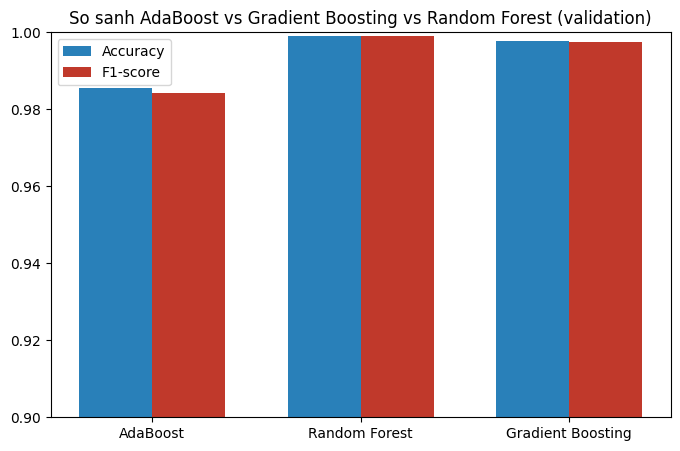

,model,accuracy,f1,train_time_s
0,AdaBoost,0.9856,0.9843,NaN
1,Random Forest,0.9990,0.9990,NaN
2,Gradient Boosting,0.9977,0.9975,165.9602


In [ ]:
gb = GradientBoostingClassifier(n_estimators=N_ESTIMATORS, learning_rate=0.05,
                                 max_depth=3, random_state=RANDOM_STATE)
t0 = time.perf_counter()
gb.fit(Xtr_sub, ytr_sub)
gb_time = time.perf_counter() - t0

ensemble_rows = []
for name, model, ttime in [("AdaBoost", ada_clean, None), ("Random Forest", rf_clean, None),
                            ("Gradient Boosting", gb, gb_time)]:
    pred = model.predict(Xval)
    ensemble_rows.append({"model": name, "accuracy": accuracy_score(yval, pred),
                           "f1": f1_score(yval, pred), "train_time_s": ttime})
    print(f"{name:20s} Accuracy={ensemble_rows[-1]['accuracy']:.4f}  F1={ensemble_rows[-1]['f1']:.4f}")

ensemble_table = pd.DataFrame(ensemble_rows)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ensemble_table)); width = 0.35
ax.bar(x - width/2, ensemble_table["accuracy"], width, label="Accuracy", color="#2980b9")
ax.bar(x + width/2, ensemble_table["f1"], width, label="F1-score", color="#c0392b")
ax.set_xticks(x); ax.set_xticklabels(ensemble_table["model"])
ax.set_ylim(0.9, 1.0)
ax.set_title("So sanh AdaBoost vs Gradient Boosting vs Random Forest (validation)")
ax.legend()
plt.show()

ensemble_table

## 9. Đánh giá trên tập test NSL-KDD gốc — nơi có tấn công chưa từng thấy

Đây là bài kiểm tra thật: huấn luyện model AdaBoost cuối cùng trên **toàn bộ**
tập train, rồi đánh giá trên tập test gốc — tập chứa 17 loại tấn công hoàn
toàn mới (mục 3). Kỳ vọng: điểm số **thấp hơn rõ rệt** so với CV ở mục 5 —
đó là tín hiệu ĐÚNG cho thấy mô hình không "học vẹt" các dạng tấn công đã
thấy, và cho ta biết mức độ tổng quát hoá thật với tấn công lạ.

In [ ]:
final_pipe = Pipeline([
    ("prep", build_preprocessor()),
    ("clf", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                n_estimators=N_ESTIMATORS, learning_rate=0.5, random_state=RANDOM_STATE)),
])
final_pipe.fit(X_train_full, y_train_full)

pred_test = final_pipe.predict(X_test)
acc_test = accuracy_score(y_test, pred_test)
f1_test = f1_score(y_test, pred_test)

print(f"F1 tren CV (train, muc 5)      = {ada_cv_f1:.4f}")
print(f"F1 tren test NSL-KDD goc       = {f1_test:.4f}")
print(f"Chenh lech CV vs test          = {ada_cv_f1 - f1_test:.4f}")
print(f"Accuracy tren test NSL-KDD goc = {acc_test:.4f}")

Path("../models").mkdir(exist_ok=True)
joblib.dump(final_pipe, "../models/adaboost.joblib")
print("Da luu models/adaboost.joblib")

F1 tren CV (train, muc 5)      = 0.9836
F1 tren test NSL-KDD goc       = 0.7576
Chenh lech CV vs test          = 0.2260
Accuracy tren test NSL-KDD goc = 0.7655
Da luu models/adaboost.joblib


## 10. Ma trận nhầm lẫn + ước tính số báo động giả/ngày (alert fatigue)

Ma trận nhầm lẫn cho biết trực tiếp: bao nhiêu kết nối `attack` bị bỏ lọt
(FN — rủi ro bảo mật), bao nhiêu kết nối `normal` bị chặn nhầm (FP — nguồn
gốc của "alert fatigue"). Từ FPR đo được trên tập test, ta quy đổi ra số báo
động giả/ngày với một **giả định về quy mô lưu lượng** (nêu rõ để không nhầm
là số liệu thực tế của một SOC cụ thể).

In [9]:
cm = confusion_matrix(y_test, pred_test)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["normal", "attack"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["normal", "attack"])
ax.set_xlabel("Du doan"); ax.set_ylabel("Thuc te")
ax.set_title("Ma tran nham lan - tap test NSL-KDD goc")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print(f"False Positive Rate (chan nham normal) = {fpr:.4%}")
print(f"False Negative Rate (bo lot attack)    = {fnr:.4%}")

ASSUMED_DAILY_CONNECTIONS = 2_000_000
normal_share = (y_test == 0).mean()
assumed_daily_normal = ASSUMED_DAILY_CONNECTIONS * normal_share
false_alarms_per_day = assumed_daily_normal * fpr
print(f"\nGia dinh: SOC xu ly {ASSUMED_DAILY_CONNECTIONS:,} ket noi/ngay "
      f"({normal_share:.1%} la normal trong phan bo tap test)")
print(f"-> Uoc tinh {false_alarms_per_day:,.0f} bao dong gia/ngay o nguong mac dinh (predict, 0.5)")


NameError: name 'pred_test' is not defined

## Tổng kết

| Hạng mục | Kết quả |
| :--- | :--- |
| 1 stump vs 300 stump (5-fold CV) | xem bảng mục 5 |
| F1 theo n_estimators | xem đường cong mục 6 |
| ⭐ Thí nghiệm nhiễu nhãn | xem bảng + biểu đồ mục 7 |
| So sánh AdaBoost / Gradient Boosting / Random Forest | xem bảng mục 8 |
| Chênh lệch CV vs test NSL-KDD gốc | xem mục 9 — mô phỏng zero-day |
| Ma trận nhầm lẫn + báo động giả/ngày | xem mục 10 |

**Hạn chế cần nêu rõ:**
1. Giả định quy mô lưu lượng (2 triệu kết nối/ngày) chỉ để minh hoạ phương
   pháp tính báo động giả, không phải số liệu thực tế của một SOC cụ thể.
2. NSL-KDD được thu thập từ môi trường mô phỏng (1998-1999, cải tiến 2009) —
   các kỹ thuật tấn công hiện đại có thể không được phản ánh đầy đủ.
3. Bài toán nhị phân bỏ qua sự khác biệt mức độ nghiêm trọng giữa các nhóm
   tấn công (DoS ồn ào >< U2R âm thầm nhưng nguy hiểm hơn) — xem hướng mở
   rộng đa lớp (`SAMME`) trong `README.md`.

Số liệu đầy đủ (bảng CV, thí nghiệm nhiễu, so sánh ensemble, tóm tắt JSON)
được lưu lại trong thư mục `../reports/` bởi `src/train.py` — notebook này
dùng để **giải thích lý do và cách đọc** từng bước, còn script dùng để tái
lập kết quả tự động.